# ***1. Codigo Paso a Paso***

## ***1.1 GPU***

In [3]:
!pip install numba opencv-python-headless matplotlib numpy pynvjitlink-cu12 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 9.9 MB/s eta 0:00:00


In [4]:
from google.colab import files
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from numba import config

config.CUDA_ENABLE_PYNVJITLINK = 1

In [243]:
def generar_video_prueba(nombre="asteroide_test.mp4", frames=90, width=640, height=480):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(nombre, fourcc, 30, (width, height))

    hay_asteroide = random.choice([True, False])
    trayectoria_tipo = None
    velocidad = None

    print(f"¿Hay asteroide?: {'SÍ' if hay_asteroide else 'NO'}")

    if hay_asteroide:
        trayectoria_tipo = random.choice(["lineal", "diagonal_inversa", "curva", "cambio_rumbo", "zigzag"])
        velocidad = random.choice(["lenta", "normal", "rapida"])
        print(f"Tipo de trayectoria: {trayectoria_tipo}")
        print(f"Velocidad: {velocidad}")

    factor_velocidad = {"lenta": 0.4, "normal": 1.0, "rapida": 2.2}.get(velocidad, 1.0)

    nebulosas = [(random.randint(100, width-100), random.randint(50, height-50),
                  random.randint(40, 90), (random.randint(5,20), random.randint(3,12), random.randint(5,25)))
                 for _ in range(random.randint(2, 4))]

    for t in range(frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)

        for y in range(height):
            val = int(3 + 8 * y / height)
            frame[y, :] = [val//2, val//3, val]

        for (cx, cy, r, color) in nebulosas:
            for dy in range(-r, r):
                for dx in range(-r, r):
                    dist = (dx**2 + dy**2)**0.5
                    if dist < r:
                        px, py = cx+dx, cy+dy
                        if 0 <= px < width and 0 <= py < height:
                            intensidad = int(color[0] * (1 - dist/r))
                            frame[py, px] = np.clip(
                                frame[py, px] + [intensidad, int(intensidad*color[1]/color[0]), int(intensidad*color[2]/color[0])],
                                0, 255
                            )

        n_estrellas = random.randint(180, 280)
        for _ in range(n_estrellas):
            sx = random.randint(0, width-1)
            sy = random.randint(0, height-1)
            brillo = random.randint(100, 255)
            tamanio = random.choices([1, 2, 3], weights=[70, 25, 5])[0]
            color_estrella = random.choice([
                (brillo, brillo, brillo),
                (brillo, brillo, int(brillo*0.7)),
                (int(brillo*0.7), int(brillo*0.8), brillo),
                (brillo, int(brillo*0.7), int(brillo*0.7)),
            ])
            cv2.circle(frame, (sx, sy), tamanio, color_estrella, -1)

        ruido = np.random.randint(0, 20, (height, width, 3), dtype=np.uint8)
        frame = cv2.add(frame, ruido)

        if hay_asteroide:
            progreso = min((t / frames) * factor_velocidad, 1.0)

            if trayectoria_tipo == "lineal":
                x = int(30 + (width - 60) * progreso)
                y = int(height * 0.35)

            elif trayectoria_tipo == "diagonal_inversa":
                x = int(width - 30 - (width - 60) * progreso)
                y = int(30 + (height - 60) * progreso)

            elif trayectoria_tipo == "curva":
                x = int(30 + (width - 60) * progreso)
                y = int(height//2 + np.sin(progreso * np.pi * 2.5) * 130)

            elif trayectoria_tipo == "cambio_rumbo":
                if progreso < 0.5:
                    x = int(30 + (width//2) * (progreso * 2))
                    y = int(60 + (height//2) * (progreso * 2))
                else:
                    p2 = (progreso - 0.5) * 2
                    x = int(width//2 + (width//2 - 30) * p2)
                    y = int(height//2 - (height//3) * p2)

            elif trayectoria_tipo == "zigzag":
                x = int(30 + (width - 60) * progreso)
                y = int(height//2 + (1 if int(progreso*6) % 2 == 0 else -1) * 80)

            cv2.circle(frame, (x, y), 18, (45, 38, 30), -1)
            cv2.circle(frame, (x, y), 14, (90, 75, 55), -1)
            cv2.circle(frame, (x, y), 10, (120, 100, 75), -1)
            cv2.circle(frame, (x, y),  6, (160, 135, 100), -1)
            cv2.circle(frame, (x-3, y-3), 3, (200, 175, 140), -1)

            overlay = frame.copy()
            cv2.circle(overlay, (x, y), 22, (255, 220, 150), -1)
            frame = cv2.addWeighted(frame, 0.92, overlay, 0.08, 0)

        out.write(frame)

    out.release()
    print(f"Video generado: {nombre} ({frames} frames)")
    return hay_asteroide

hay_asteroide_real = generar_video_prueba()

¿Hay asteroide?: SÍ
Tipo de trayectoria: curva
Velocidad: lenta
Video generado: asteroide_test.mp4 (90 frames)


In [244]:
!ffmpeg -y -i asteroide_test.mp4 -vcodec libx264 -crf 23 asteroide_test_h264.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [245]:
mostrar_video("asteroide_test_h264.mp4")

In [246]:
# --- KERNEL CUDA: RGB a Escala de Grises ---
@cuda.jit
def grayscale_kernel(frame_color, frame_gray):
    j, i = cuda.grid(2)
    rows, cols = frame_gray.shape
    if i < rows and j < cols:
        R = frame_color[i, j, 0]
        G = frame_color[i, j, 1]
        B = frame_color[i, j, 2]
        frame_gray[i, j] = 0.2989 * R + 0.5870 * G + 0.1140 * B


def frame_a_gris_gpu(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    rows, cols, _ = frame_rgb.shape

    d_color = cuda.to_device(frame_rgb)
    d_gray  = cuda.device_array((rows, cols), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (cols + 15) // 16
    blockspergrid_y = (rows + 15) // 16
    blockspergrid   = (blockspergrid_x, blockspergrid_y)

    grayscale_kernel[blockspergrid, threadsperblock](d_color, d_gray)

    return d_gray.copy_to_host()


def extraer_frames_grises(nombre_video):
    cap = cv2.VideoCapture(nombre_video)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_gris = frame_a_gris_gpu(frame)
        frames.append(frame_gris)

    cap.release()
    print(f"Frames extraídos: {len(frames)}, resolución: {frames[0].shape}")
    return frames

frames_grises = extraer_frames_grises("asteroide_test.mp4")

Frames extraídos: 90, resolución: (480, 640)


In [247]:
# --- KERNEL CUDA: Filtro de suavizado 3x3 ---
@cuda.jit
def filtro_suavizado_kernel(frame_in, frame_out):
    j, i = cuda.grid(2)
    rows, cols = frame_in.shape

    if i < rows and j < cols:
        suma = 0.0
        count = 0
        for di in range(-1, 2):
            for dj in range(-1, 2):
                ni = i + di
                nj = j + dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    suma += frame_in[ni, nj]
                    count += 1
        frame_out[i, j] = suma / count


def suavizar_frame_gpu(frame_gray):
    rows, cols = frame_gray.shape

    d_in  = cuda.to_device(frame_gray.astype(np.float32))
    d_out = cuda.device_array((rows, cols), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (cols + 15) // 16
    blockspergrid_y = (rows + 15) // 16
    blockspergrid   = (blockspergrid_x, blockspergrid_y)

    filtro_suavizado_kernel[blockspergrid, threadsperblock](d_in, d_out)

    return d_out.copy_to_host()


frames_suavizados = [suavizar_frame_gpu(f) for f in frames_grises]
print(f"Suavizado aplicado a {len(frames_suavizados)} frames")

Suavizado aplicado a 90 frames


In [248]:
# --- KERNEL CUDA: Sustracción de fondo entre frame actual y anterior ---
@cuda.jit
def diferencia_temporal_kernel(frame_actual, frame_anterior, frame_diff):
    j, i = cuda.grid(2)
    rows, cols = frame_actual.shape

    if i < rows and j < cols:
        frame_diff[i, j] = abs(frame_actual[i, j] - frame_anterior[i, j])


def diferencia_temporal_gpu(frame_actual, frame_anterior):
    rows, cols = frame_actual.shape

    d_actual   = cuda.to_device(frame_actual.astype(np.float32))
    d_anterior = cuda.to_device(frame_anterior.astype(np.float32))
    d_diff     = cuda.device_array((rows, cols), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (cols + 15) // 16
    blockspergrid_y = (rows + 15) // 16
    blockspergrid   = (blockspergrid_x, blockspergrid_y)

    diferencia_temporal_kernel[blockspergrid, threadsperblock](d_actual, d_anterior, d_diff)

    return d_diff.copy_to_host()


SALTO = 4

frames_diff = []
for t in range(SALTO, len(frames_suavizados)):
    diff = diferencia_temporal_gpu(frames_suavizados[t], frames_suavizados[t - SALTO])
    frames_diff.append(diff)

print(f"Diferencias temporales calculadas: {len(frames_diff)} frames")

Diferencias temporales calculadas: 86 frames


In [249]:
# --- KERNEL CUDA: Umbralización binaria ---
@cuda.jit
def umbral_kernel(frame_diff, frame_bin, umbral):
    j, i = cuda.grid(2)
    rows, cols = frame_diff.shape

    if i < rows and j < cols:
        if frame_diff[i, j] >= umbral:
            frame_bin[i, j] = 255.0
        else:
            frame_bin[i, j] = 0.0


def umbralizar_gpu(frame_diff, umbral=12.0):
    rows, cols = frame_diff.shape

    d_diff = cuda.to_device(frame_diff.astype(np.float32))
    d_bin  = cuda.device_array((rows, cols), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (cols + 15) // 16
    blockspergrid_y = (rows + 15) // 16
    blockspergrid   = (blockspergrid_x, blockspergrid_y)

    umbral_kernel[blockspergrid, threadsperblock](d_diff, d_bin, umbral)

    return d_bin.copy_to_host()


frames_bin = [umbralizar_gpu(f, umbral=30.0) for f in frames_diff]
print(f"Umbralización aplicada a {len(frames_bin)} frames")

Umbralización aplicada a 86 frames


In [250]:
# --- KERNEL CUDA: Erosión 3x3 ---
@cuda.jit
def erosion_kernel(frame_in, frame_out):
    j, i = cuda.grid(2)
    rows, cols = frame_in.shape

    if i < rows and j < cols:
        minimo = 255.0
        for di in range(-1, 2):
            for dj in range(-1, 2):
                ni = i + di
                nj = j + dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    if frame_in[ni, nj] < minimo:
                        minimo = frame_in[ni, nj]
        frame_out[i, j] = minimo


# --- KERNEL CUDA: Dilatación 3x3 ---
@cuda.jit
def dilatacion_kernel(frame_in, frame_out):
    j, i = cuda.grid(2)
    rows, cols = frame_in.shape

    if i < rows and j < cols:
        maximo = 0.0
        for di in range(-1, 2):
            for dj in range(-1, 2):
                ni = i + di
                nj = j + dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    if frame_in[ni, nj] > maximo:
                        maximo = frame_in[ni, nj]
        frame_out[i, j] = maximo


def morfologia_gpu(frame_bin):
    rows, cols = frame_bin.shape

    threadsperblock = (16, 16)
    blockspergrid_x = (cols + 15) // 16
    blockspergrid_y = (rows + 15) // 16
    blockspergrid   = (blockspergrid_x, blockspergrid_y)

    d_in      = cuda.to_device(frame_bin.astype(np.float32))
    d_eroded  = cuda.device_array((rows, cols), dtype=np.float32)
    erosion_kernel[blockspergrid, threadsperblock](d_in, d_eroded)

    d_dilated = cuda.device_array((rows, cols), dtype=np.float32)
    dilatacion_kernel[blockspergrid, threadsperblock](d_eroded, d_dilated)

    return d_dilated.copy_to_host()


frames_morfologia = [morfologia_gpu(f) for f in frames_bin]
print(f"Morfología aplicada a {len(frames_morfologia)} frames")

Morfología aplicada a 86 frames


In [251]:
def extraer_centroide(frame_bin):
    pixeles_blancos = np.argwhere(frame_bin == 255)
    if len(pixeles_blancos) < 20:
        return None

    rows, cols = frame_bin.shape
    tam_bloque = 32
    max_densidad = 0
    mejor_bloque = None

    for bi in range(0, rows, tam_bloque):
        for bj in range(0, cols, tam_bloque):
            bloque = frame_bin[bi:bi+tam_bloque, bj:bj+tam_bloque]
            densidad = np.sum(bloque == 255)
            if densidad > max_densidad:
                max_densidad = densidad
                mejor_bloque = (bi, bj)

    if max_densidad < 32 * 32 * 0.15:
        return None

    bi, bj = mejor_bloque
    bloque_mask = frame_bin[bi:bi+tam_bloque, bj:bj+tam_bloque]
    puntos = np.argwhere(bloque_mask == 255)
    cy = int(np.mean(puntos[:, 0])) + bi
    cx = int(np.mean(puntos[:, 1])) + bj

    return (cx, cy)


trayectoria = []
detecciones_raw = []

for t, frame in enumerate(frames_morfologia):
    centroide = extraer_centroide(frame)
    detecciones_raw.append((t, centroide))

MIN_FRAMES_CONSECUTIVOS = 5
consecutivos = 0

for t, centroide in detecciones_raw:
    if centroide is not None:
        consecutivos += 1
        if consecutivos >= MIN_FRAMES_CONSECUTIVOS:
            trayectoria.append((t, centroide[0], centroide[1]))
    else:
        consecutivos = 0

print(f"Puntos de trayectoria detectados: {len(trayectoria)}")

if len(trayectoria) > 0:
    print("Veredicto: EXISTE ASTEROIDE ☄️")
else:
    print("Veredicto: NO EXISTE ASTEROIDE 🌌")

Puntos de trayectoria detectados: 82
Veredicto: EXISTE ASTEROIDE ☄️


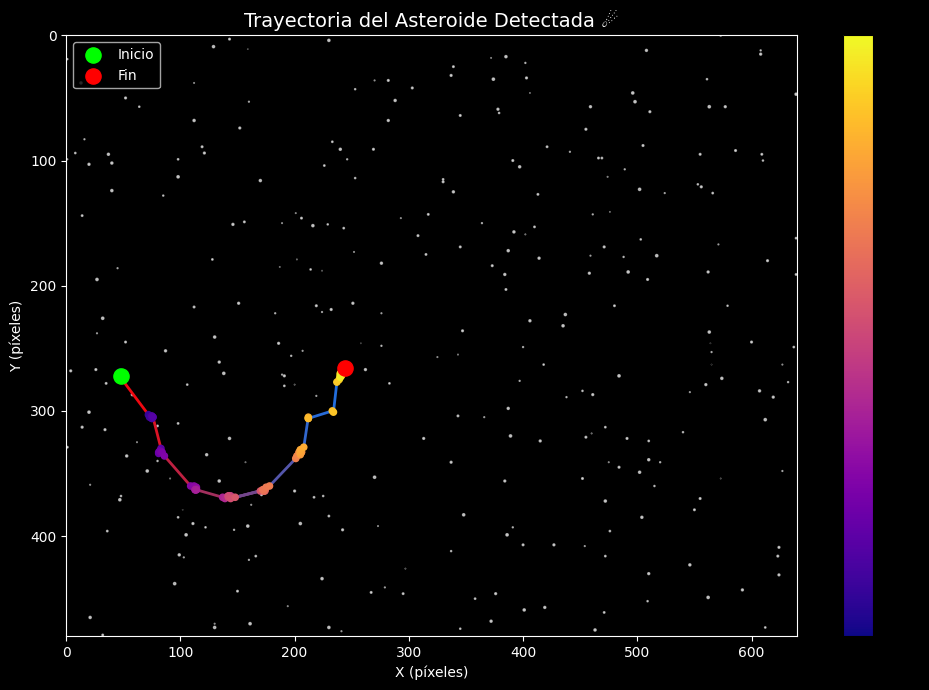

In [252]:
def graficar_trayectoria(trayectoria, hay_asteroide, width=640, height=480):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')

    np.random.seed(42)
    estrellas_x = np.random.randint(0, width, 300)
    estrellas_y = np.random.randint(0, height, 300)
    brillos = np.random.rand(300)
    ax.scatter(estrellas_x, estrellas_y, s=brillos*3, c='white', alpha=0.6)

    if hay_asteroide and len(trayectoria) > 0:
        ts  = [p[0] for p in trayectoria]
        xs  = [p[1] for p in trayectoria]
        ys  = [p[2] for p in trayectoria]

        puntos = np.array([xs, ys]).T.reshape(-1, 1, 2)
        for i in range(len(puntos) - 1):
            progreso = i / len(puntos)
            color = (1 - progreso, progreso * 0.5, progreso)
            ax.plot([xs[i], xs[i+1]], [ys[i], ys[i+1]], color=color, linewidth=2)

        scatter = ax.scatter(xs, ys, c=ts, cmap='plasma', s=20, zorder=5)
        plt.colorbar(scatter, ax=ax, label='Frame')

        ax.scatter(xs[0],  ys[0],  s=120, c='lime',   zorder=6, label='Inicio')
        ax.scatter(xs[-1], ys[-1], s=120, c='red',    zorder=6, label='Fin')
        ax.legend(facecolor='black', labelcolor='white')

        ax.set_title('Trayectoria del Asteroide Detectada ☄️', color='white', fontsize=14)
    else:
        ax.set_title('No se detectó ningún asteroide 🌌', color='white', fontsize=14)

    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_xlabel('X (píxeles)', color='white')
    ax.set_ylabel('Y (píxeles)', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

    plt.tight_layout()
    plt.show()

graficar_trayectoria(trayectoria, len(trayectoria) > 0)

## ***2. CPU***

In [266]:
import time

# --- CPU: Escala de grises ---
def frame_a_gris_cpu(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R, G, B = frame_rgb[:,:,0], frame_rgb[:,:,1], frame_rgb[:,:,2]
    return 0.2989 * R + 0.5870 * G + 0.1140 * B


# --- CPU: Filtro suavizado 3x3 ---
def suavizar_frame_cpu(frame_gray):
    rows, cols = frame_gray.shape
    out = np.zeros_like(frame_gray)
    for i in range(rows):
        for j in range(cols):
            vals = []
            for di in range(-1, 2):
                for dj in range(-1, 2):
                    ni, nj = i+di, j+dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        vals.append(frame_gray[ni, nj])
            out[i, j] = np.mean(vals)
    return out


# --- CPU: Diferencia temporal ---
def diferencia_temporal_cpu(frame_actual, frame_anterior):
    return np.abs(frame_actual.astype(np.float32) - frame_anterior.astype(np.float32))


# --- CPU: Umbralización ---
def umbralizar_cpu(frame_diff, umbral=30.0):
    out = np.zeros_like(frame_diff)
    out[frame_diff >= umbral] = 255.0
    return out


# --- CPU: Erosión 3x3 ---
def erosion_cpu(frame_bin):
    rows, cols = frame_bin.shape
    out = np.zeros_like(frame_bin)
    for i in range(rows):
        for j in range(cols):
            minimo = 255.0
            for di in range(-1, 2):
                for dj in range(-1, 2):
                    ni, nj = i+di, j+dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        if frame_bin[ni, nj] < minimo:
                            minimo = frame_bin[ni, nj]
            out[i, j] = minimo
    return out


# --- CPU: Dilatación 3x3 ---
def dilatacion_cpu(frame_bin):
    rows, cols = frame_bin.shape
    out = np.zeros_like(frame_bin)
    for i in range(rows):
        for j in range(cols):
            maximo = 0.0
            for di in range(-1, 2):
                for dj in range(-1, 2):
                    ni, nj = i+di, j+dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        if frame_bin[ni, nj] > maximo:
                            maximo = frame_bin[ni, nj]
            out[i, j] = maximo
    return out


# --- Pipeline CPU completo ---
def pipeline_cpu(nombre_video):
    cap = cv2.VideoCapture(nombre_video)
    frames_grises_cpu = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames_grises_cpu.append(frame_a_gris_cpu(frame))
    cap.release()

    SALTO = 4
    frames_diff_cpu      = []
    frames_bin_cpu       = []
    frames_morfologia_cpu = []

    for t in range(SALTO, len(frames_grises_cpu)):
        suav_actual   = suavizar_frame_cpu(frames_grises_cpu[t])
        suav_anterior = suavizar_frame_cpu(frames_grises_cpu[t - SALTO])
        diff          = diferencia_temporal_cpu(suav_actual, suav_anterior)
        bin_          = umbralizar_cpu(diff)
        eroded        = erosion_cpu(bin_)
        dilated       = dilatacion_cpu(eroded)
        frames_morfologia_cpu.append(dilated)

    trayectoria_cpu = []
    detecciones_raw = []
    for t, frame in enumerate(frames_morfologia_cpu):
        centroide = extraer_centroide(frame)
        detecciones_raw.append((t, centroide))

    consecutivos = 0
    for t, centroide in detecciones_raw:
        if centroide is not None:
            consecutivos += 1
            if consecutivos >= 5:
                trayectoria_cpu.append((t, centroide[0], centroide[1]))
        else:
            consecutivos = 0

    return trayectoria_cpu
    print("Iniciando pipeline CPU... (puede tardar varios minutos)")
inicio = time.time()
trayectoria_cpu = pipeline_cpu("asteroide_test_h264.mp4")
fin = time.time()
tiempo_cpu = fin - inicio

print(f"Tiempo CPU: {tiempo_cpu:.2f} segundos")
print(f"Puntos detectados CPU: {len(trayectoria_cpu)}")

if len(trayectoria_cpu) > 0:
    print("Veredicto CPU: EXISTE ASTEROIDE ☄️")
else:
    print("Veredicto CPU: NO EXISTE ASTEROIDE 🌌")

Tiempo CPU: 928.63 segundos
Puntos detectados CPU: 82
Veredicto CPU: EXISTE ASTEROIDE ☄️


In [267]:
print("Iniciando pipeline GPU...")
inicio = time.time()

cap = cv2.VideoCapture("asteroide_test_h264.mp4")
frames_grises_gpu = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames_grises_gpu.append(frame_a_gris_gpu(frame))
cap.release()

frames_suavizados_gpu = [suavizar_frame_gpu(f) for f in frames_grises_gpu]

SALTO = 4
frames_diff_gpu = []
for t in range(SALTO, len(frames_suavizados_gpu)):
    diff = diferencia_temporal_gpu(frames_suavizados_gpu[t], frames_suavizados_gpu[t - SALTO])
    frames_diff_gpu.append(diff)

frames_bin_gpu       = [umbralizar_gpu(f, umbral=30.0) for f in frames_diff_gpu]
frames_morfologia_gpu = [morfologia_gpu(f) for f in frames_bin_gpu]

trayectoria_gpu = []
detecciones_raw = []
for t, frame in enumerate(frames_morfologia_gpu):
    centroide = extraer_centroide(frame)
    detecciones_raw.append((t, centroide))

consecutivos = 0
for t, centroide in detecciones_raw:
    if centroide is not None:
        consecutivos += 1
        if consecutivos >= 5:
            trayectoria_gpu.append((t, centroide[0], centroide[1]))
    else:
        consecutivos = 0

fin = time.time()
tiempo_gpu = fin - inicio

print(f"Tiempo GPU: {tiempo_gpu:.2f} segundos")
print(f"Puntos detectados GPU: {len(trayectoria_gpu)}")
if len(trayectoria_gpu) > 0:
    print("Veredicto GPU: EXISTE ASTEROIDE ☄️")
else:
    print("Veredicto GPU: NO EXISTE ASTEROIDE 🌌")

Iniciando pipeline GPU...
Tiempo GPU: 1.94 segundos
Puntos detectados GPU: 82
Veredicto GPU: EXISTE ASTEROIDE ☄️


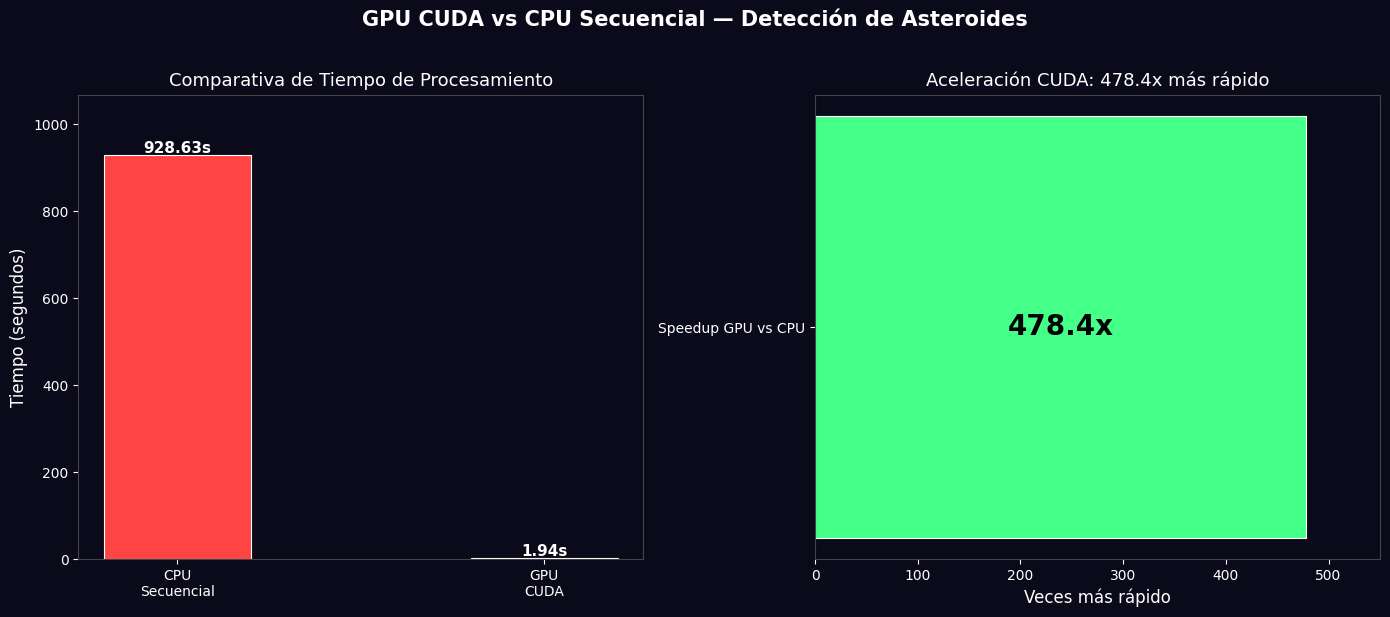


Resumen:
  Tiempo CPU  : 928.63 s
  Tiempo GPU  : 1.94 s
  Speedup     : 478.4x
  Reducción   : 99.8% menos tiempo


In [268]:
def graficar_comparativa(tiempo_cpu, tiempo_gpu):
    speedup = tiempo_cpu / tiempo_gpu

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#0a0a1a')

    # --- Gráfica de barras de tiempos ---
    ax1 = axes[0]
    ax1.set_facecolor('#0a0a1a')
    barras = ax1.bar(['CPU\nSecuencial', 'GPU\nCUDA'],
                     [tiempo_cpu, tiempo_gpu],
                     color=['#ff4444', '#44aaff'],
                     width=0.4, edgecolor='white', linewidth=0.8)

    ax1.set_ylabel('Tiempo (segundos)', color='white', fontsize=12)
    ax1.set_title('Comparativa de Tiempo de Procesamiento', color='white', fontsize=13)
    ax1.tick_params(colors='white')
    for spine in ax1.spines.values():
        spine.set_edgecolor('#444444')

    for barra, valor in zip(barras, [tiempo_cpu, tiempo_gpu]):
        ax1.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 5,
                 f'{valor:.2f}s', ha='center', color='white', fontsize=11, fontweight='bold')

    ax1.set_ylim(0, tiempo_cpu * 1.15)

    # --- Gráfica de speedup ---
    ax2 = axes[1]
    ax2.set_facecolor('#0a0a1a')
    ax2.barh(['Speedup GPU vs CPU'], [speedup], color='#44ff88', edgecolor='white', linewidth=0.8)
    ax2.set_xlabel('Veces más rápido', color='white', fontsize=12)
    ax2.set_title(f'Aceleración CUDA: {speedup:.1f}x más rápido', color='white', fontsize=13)
    ax2.tick_params(colors='white')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444444')
    ax2.text(speedup * 0.5, 0, f'{speedup:.1f}x', ha='center', va='center',
             color='black', fontsize=20, fontweight='bold')
    ax2.set_xlim(0, speedup * 1.15)

    plt.suptitle('GPU CUDA vs CPU Secuencial — Detección de Asteroides',
                 color='white', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\nResumen:")
    print(f"  Tiempo CPU  : {tiempo_cpu:.2f} s")
    print(f"  Tiempo GPU  : {tiempo_gpu:.2f} s")
    print(f"  Speedup     : {speedup:.1f}x")
    print(f"  Reducción   : {((tiempo_cpu - tiempo_gpu) / tiempo_cpu * 100):.1f}% menos tiempo")

graficar_comparativa(tiempo_cpu, tiempo_gpu)

# ***2. Codigo Unificado***

In [269]:
# ============================================================
#   CPU vs GPU (CUDA)
# ============================================================

from google.colab import files
import cv2
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

# ============================================================
# KERNELS CUDA
# ============================================================

@cuda.jit
def grayscale_kernel(frame_color, frame_gray):
    j, i = cuda.grid(2)
    rows, cols = frame_gray.shape
    if i < rows and j < cols:
        R = frame_color[i, j, 0]
        G = frame_color[i, j, 1]
        B = frame_color[i, j, 2]
        frame_gray[i, j] = 0.2989 * R + 0.5870 * G + 0.1140 * B

@cuda.jit
def filtro_suavizado_kernel(frame_in, frame_out):
    j, i = cuda.grid(2)
    rows, cols = frame_in.shape
    if i < rows and j < cols:
        suma = 0.0
        count = 0
        for di in range(-1, 2):
            for dj in range(-1, 2):
                ni, nj = i+di, j+dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    suma += frame_in[ni, nj]
                    count += 1
        frame_out[i, j] = suma / count

@cuda.jit
def diferencia_temporal_kernel(frame_actual, frame_anterior, frame_diff):
    j, i = cuda.grid(2)
    rows, cols = frame_actual.shape
    if i < rows and j < cols:
        frame_diff[i, j] = abs(frame_actual[i, j] - frame_anterior[i, j])

@cuda.jit
def umbral_kernel(frame_diff, frame_bin, umbral):
    j, i = cuda.grid(2)
    rows, cols = frame_diff.shape
    if i < rows and j < cols:
        frame_bin[i, j] = 255.0 if frame_diff[i, j] >= umbral else 0.0

@cuda.jit
def erosion_kernel(frame_in, frame_out):
    j, i = cuda.grid(2)
    rows, cols = frame_in.shape
    if i < rows and j < cols:
        minimo = 255.0
        for di in range(-1, 2):
            for dj in range(-1, 2):
                ni, nj = i+di, j+dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    if frame_in[ni, nj] < minimo:
                        minimo = frame_in[ni, nj]
        frame_out[i, j] = minimo

@cuda.jit
def dilatacion_kernel(frame_in, frame_out):
    j, i = cuda.grid(2)
    rows, cols = frame_in.shape
    if i < rows and j < cols:
        maximo = 0.0
        for di in range(-1, 2):
            for dj in range(-1, 2):
                ni, nj = i+di, j+dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    if frame_in[ni, nj] > maximo:
                        maximo = frame_in[ni, nj]
        frame_out[i, j] = maximo

# ============================================================
# FUNCIONES GPU
# ============================================================

def gpu_config(rows, cols):
    threadsperblock = (16, 16)
    blockspergrid   = ((cols + 15) // 16, (rows + 15) // 16)
    return threadsperblock, blockspergrid

def frame_a_gris_gpu(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    rows, cols, _ = frame_rgb.shape
    d_color = cuda.to_device(frame_rgb)
    d_gray  = cuda.device_array((rows, cols), dtype=np.float32)
    tpb, bpg = gpu_config(rows, cols)
    grayscale_kernel[bpg, tpb](d_color, d_gray)
    return d_gray.copy_to_host()

def suavizar_frame_gpu(frame_gray):
    rows, cols = frame_gray.shape
    d_in  = cuda.to_device(frame_gray.astype(np.float32))
    d_out = cuda.device_array((rows, cols), dtype=np.float32)
    tpb, bpg = gpu_config(rows, cols)
    filtro_suavizado_kernel[bpg, tpb](d_in, d_out)
    return d_out.copy_to_host()

def diferencia_temporal_gpu(frame_actual, frame_anterior):
    rows, cols = frame_actual.shape
    d_actual   = cuda.to_device(frame_actual.astype(np.float32))
    d_anterior = cuda.to_device(frame_anterior.astype(np.float32))
    d_diff     = cuda.device_array((rows, cols), dtype=np.float32)
    tpb, bpg   = gpu_config(rows, cols)
    diferencia_temporal_kernel[bpg, tpb](d_actual, d_anterior, d_diff)
    return d_diff.copy_to_host()

def umbralizar_gpu(frame_diff, umbral=30.0):
    rows, cols = frame_diff.shape
    d_diff = cuda.to_device(frame_diff.astype(np.float32))
    d_bin  = cuda.device_array((rows, cols), dtype=np.float32)
    tpb, bpg = gpu_config(rows, cols)
    umbral_kernel[bpg, tpb](d_diff, d_bin, umbral)
    return d_bin.copy_to_host()

def morfologia_gpu(frame_bin):
    rows, cols = frame_bin.shape
    tpb, bpg  = gpu_config(rows, cols)
    d_in      = cuda.to_device(frame_bin.astype(np.float32))
    d_eroded  = cuda.device_array((rows, cols), dtype=np.float32)
    erosion_kernel[bpg, tpb](d_in, d_eroded)
    d_dilated = cuda.device_array((rows, cols), dtype=np.float32)
    dilatacion_kernel[bpg, tpb](d_eroded, d_dilated)
    return d_dilated.copy_to_host()

# ============================================================
# FUNCIONES CPU
# ============================================================

def frame_a_gris_cpu(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R, G, B = frame_rgb[:,:,0], frame_rgb[:,:,1], frame_rgb[:,:,2]
    return 0.2989 * R + 0.5870 * G + 0.1140 * B

def suavizar_frame_cpu(frame_gray):
    rows, cols = frame_gray.shape
    out = np.zeros_like(frame_gray)
    for i in range(rows):
        for j in range(cols):
            vals = []
            for di in range(-1, 2):
                for dj in range(-1, 2):
                    ni, nj = i+di, j+dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        vals.append(frame_gray[ni, nj])
            out[i, j] = np.mean(vals)
    return out

def diferencia_temporal_cpu(frame_actual, frame_anterior):
    return np.abs(frame_actual.astype(np.float32) - frame_anterior.astype(np.float32))

def umbralizar_cpu(frame_diff, umbral=30.0):
    out = np.zeros_like(frame_diff)
    out[frame_diff >= umbral] = 255.0
    return out

def erosion_cpu(frame_bin):
    rows, cols = frame_bin.shape
    out = np.zeros_like(frame_bin)
    for i in range(rows):
        for j in range(cols):
            minimo = 255.0
            for di in range(-1, 2):
                for dj in range(-1, 2):
                    ni, nj = i+di, j+dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        if frame_bin[ni, nj] < minimo:
                            minimo = frame_bin[ni, nj]
            out[i, j] = minimo
    return out

def dilatacion_cpu(frame_bin):
    rows, cols = frame_bin.shape
    out = np.zeros_like(frame_bin)
    for i in range(rows):
        for j in range(cols):
            maximo = 0.0
            for di in range(-1, 2):
                for dj in range(-1, 2):
                    ni, nj = i+di, j+dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        if frame_bin[ni, nj] > maximo:
                            maximo = frame_bin[ni, nj]
            out[i, j] = maximo
    return out

# ============================================================
# DETECCIÓN DE CENTROIDE
# ============================================================

def extraer_centroide(frame_bin):
    pixeles_blancos = np.argwhere(frame_bin == 255)
    if len(pixeles_blancos) < 20:
        return None
    rows, cols = frame_bin.shape
    tam_bloque  = 32
    max_densidad = 0
    mejor_bloque = None
    for bi in range(0, rows, tam_bloque):
        for bj in range(0, cols, tam_bloque):
            densidad = np.sum(frame_bin[bi:bi+tam_bloque, bj:bj+tam_bloque] == 255)
            if densidad > max_densidad:
                max_densidad = densidad
                mejor_bloque = (bi, bj)
    if max_densidad < 32 * 32 * 0.15:
        return None
    bi, bj     = mejor_bloque
    puntos     = np.argwhere(frame_bin[bi:bi+tam_bloque, bj:bj+tam_bloque] == 255)
    cy         = int(np.mean(puntos[:, 0])) + bi
    cx         = int(np.mean(puntos[:, 1])) + bj
    return (cx, cy)

def extraer_trayectoria(frames_morfologia):
    detecciones_raw = [(t, extraer_centroide(f)) for t, f in enumerate(frames_morfologia)]
    trayectoria, consecutivos = [], 0
    for t, centroide in detecciones_raw:
        if centroide is not None:
            consecutivos += 1
            if consecutivos >= 5:
                trayectoria.append((t, centroide[0], centroide[1]))
        else:
            consecutivos = 0
    return trayectoria

# ============================================================
# PIPELINES
# ============================================================

def pipeline_gpu(nombre_video, salto=4, umbral=30.0):
    cap = cv2.VideoCapture(nombre_video)
    frames_grises = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames_grises.append(frame_a_gris_gpu(frame))
    cap.release()

    frames_suav = [suavizar_frame_gpu(f) for f in frames_grises]
    frames_diff = [diferencia_temporal_gpu(frames_suav[t], frames_suav[t-salto])
                   for t in range(salto, len(frames_suav))]
    frames_bin  = [umbralizar_gpu(f, umbral) for f in frames_diff]
    frames_morf = [morfologia_gpu(f) for f in frames_bin]
    return extraer_trayectoria(frames_morf)

def pipeline_cpu(nombre_video, salto=4, umbral=30.0):
    cap = cv2.VideoCapture(nombre_video)
    frames_grises = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames_grises.append(frame_a_gris_cpu(frame))
    cap.release()

    frames_morf = []
    for t in range(salto, len(frames_grises)):
        suav_act = suavizar_frame_cpu(frames_grises[t])
        suav_ant = suavizar_frame_cpu(frames_grises[t-salto])
        diff     = diferencia_temporal_cpu(suav_act, suav_ant)
        bin_     = umbralizar_cpu(diff, umbral)
        eroded   = erosion_cpu(bin_)
        dilated  = dilatacion_cpu(eroded)
        frames_morf.append(dilated)
    return extraer_trayectoria(frames_morf)

# ============================================================
# VISUALIZACIÓN
# ============================================================

def graficar_trayectoria(trayectoria, width=640, height=480):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    np.random.seed(42)
    sx = np.random.randint(0, width, 300)
    sy = np.random.randint(0, height, 300)
    ax.scatter(sx, sy, s=np.random.rand(300)*3, c='white', alpha=0.6)

    if len(trayectoria) > 0:
        ts = [p[0] for p in trayectoria]
        xs = [p[1] for p in trayectoria]
        ys = [p[2] for p in trayectoria]
        for i in range(len(xs) - 1):
            progreso = i / len(xs)
            ax.plot([xs[i], xs[i+1]], [ys[i], ys[i+1]],
                    color=(1-progreso, progreso*0.5, progreso), linewidth=2)
        scatter = ax.scatter(xs, ys, c=ts, cmap='plasma', s=20, zorder=5)
        plt.colorbar(scatter, ax=ax, label='Frame')
        ax.scatter(xs[0],  ys[0],  s=120, c='lime', zorder=6, label='Inicio')
        ax.scatter(xs[-1], ys[-1], s=120, c='red',  zorder=6, label='Fin')
        ax.legend(facecolor='black', labelcolor='white')
        ax.set_title('Trayectoria del Asteroide Detectada ☄️', color='white', fontsize=14)
    else:
        ax.set_title('No se detectó ningún asteroide 🌌', color='white', fontsize=14)

    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_xlabel('X (píxeles)', color='white')
    ax.set_ylabel('Y (píxeles)', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    plt.tight_layout()
    plt.show()

def graficar_comparativa(tiempo_cpu, tiempo_gpu):
    speedup = tiempo_cpu / tiempo_gpu
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#0a0a1a')

    ax1 = axes[0]
    ax1.set_facecolor('#0a0a1a')
    barras = ax1.bar(['CPU\nSecuencial', 'GPU\nCUDA'],
                     [tiempo_cpu, tiempo_gpu],
                     color=['#ff4444', '#44aaff'],
                     width=0.4, edgecolor='white', linewidth=0.8)
    ax1.set_ylabel('Tiempo (segundos)', color='white', fontsize=12)
    ax1.set_title('Comparativa de Tiempo', color='white', fontsize=13)
    ax1.tick_params(colors='white')
    for spine in ax1.spines.values():
        spine.set_edgecolor('#444444')
    for barra, valor in zip(barras, [tiempo_cpu, tiempo_gpu]):
        ax1.text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + 5,
                 f'{valor:.2f}s', ha='center', color='white',
                 fontsize=11, fontweight='bold')
    ax1.set_ylim(0, tiempo_cpu * 1.15)

    ax2 = axes[1]
    ax2.set_facecolor('#0a0a1a')
    ax2.barh(['Speedup'], [speedup], color='#44ff88', edgecolor='white', linewidth=0.8)
    ax2.set_xlabel('Veces más rápido', color='white', fontsize=12)
    ax2.set_title(f'Aceleración CUDA: {speedup:.1f}x', color='white', fontsize=13)
    ax2.tick_params(colors='white')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444444')
    ax2.text(speedup*0.5, 0, f'{speedup:.1f}x',
             ha='center', va='center', color='black',
             fontsize=20, fontweight='bold')
    ax2.set_xlim(0, speedup * 1.15)

    plt.suptitle('GPU CUDA vs CPU Secuencial — Detección de Asteroides',
                 color='white', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"\n{'='*40}")
    print(f"  Tiempo CPU  : {tiempo_cpu:.2f} s")
    print(f"  Tiempo GPU  : {tiempo_gpu:.2f} s")
    print(f"  Speedup     : {speedup:.1f}x")
    print(f"  Reducción   : {((tiempo_cpu - tiempo_gpu)/tiempo_cpu*100):.1f}% menos tiempo")
    print(f"{'='*40}")

# ============================================================
# GENERADOR DE VIDEO
# ============================================================

def generar_video_prueba(nombre="asteroide_test.mp4", frames=90, width=640, height=480):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(nombre, fourcc, 30, (width, height))

    hay_asteroide    = random.choice([True, False])
    trayectoria_tipo = None
    velocidad        = None

    print(f"¿Hay asteroide?: {'SÍ' if hay_asteroide else 'NO'}")
    if hay_asteroide:
        trayectoria_tipo = random.choice(["lineal", "diagonal_inversa", "curva", "cambio_rumbo", "zigzag"])
        velocidad        = random.choice(["lenta", "normal", "rapida"])
        print(f"Tipo de trayectoria: {trayectoria_tipo}")
        print(f"Velocidad: {velocidad}")

    factor_velocidad = {"lenta": 0.4, "normal": 1.0, "rapida": 2.2}.get(velocidad, 1.0)
    nebulosas = [(random.randint(100, width-100), random.randint(50, height-50),
                  random.randint(40, 90),
                  (random.randint(5,20), random.randint(3,12), random.randint(5,25)))
                 for _ in range(random.randint(2, 4))]

    for t in range(frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)

        for y in range(height):
            val = int(3 + 8 * y / height)
            frame[y, :] = [val//2, val//3, val]

        for (cx, cy, r, color) in nebulosas:
            for dy in range(-r, r):
                for dx in range(-r, r):
                    dist = (dx**2 + dy**2)**0.5
                    if dist < r:
                        px, py = cx+dx, cy+dy
                        if 0 <= px < width and 0 <= py < height:
                            intensidad = int(color[0] * (1 - dist/r))
                            frame[py, px] = np.clip(
                                frame[py, px] + [intensidad,
                                                 int(intensidad*color[1]/color[0]),
                                                 int(intensidad*color[2]/color[0])], 0, 255)

        n_estrellas = random.randint(180, 280)
        for _ in range(n_estrellas):
            sx     = random.randint(0, width-1)
            sy     = random.randint(0, height-1)
            brillo = random.randint(100, 255)
            tam    = random.choices([1, 2, 3], weights=[70, 25, 5])[0]
            color_e = random.choice([
                (brillo, brillo, brillo),
                (brillo, brillo, int(brillo*0.7)),
                (int(brillo*0.7), int(brillo*0.8), brillo),
                (brillo, int(brillo*0.7), int(brillo*0.7)),
            ])
            cv2.circle(frame, (sx, sy), tam, color_e, -1)

        ruido = np.random.randint(0, 20, (height, width, 3), dtype=np.uint8)
        frame = cv2.add(frame, ruido)

        if hay_asteroide:
            progreso = min((t / frames) * factor_velocidad, 1.0)
            if trayectoria_tipo == "lineal":
                x = int(30 + (width-60) * progreso)
                y = int(height * 0.35)
            elif trayectoria_tipo == "diagonal_inversa":
                x = int(width-30 - (width-60) * progreso)
                y = int(30 + (height-60) * progreso)
            elif trayectoria_tipo == "curva":
                x = int(30 + (width-60) * progreso)
                y = int(height//2 + np.sin(progreso * np.pi * 2.5) * 130)
            elif trayectoria_tipo == "cambio_rumbo":
                if progreso < 0.5:
                    x = int(30 + (width//2) * (progreso*2))
                    y = int(60 + (height//2) * (progreso*2))
                else:
                    p2 = (progreso-0.5)*2
                    x  = int(width//2 + (width//2-30) * p2)
                    y  = int(height//2 - (height//3) * p2)
            elif trayectoria_tipo == "zigzag":
                x = int(30 + (width-60) * progreso)
                y = int(height//2 + (1 if int(progreso*6) % 2 == 0 else -1) * 80)

            cv2.circle(frame, (x, y), 18, (45,  38,  30),  -1)
            cv2.circle(frame, (x, y), 14, (90,  75,  55),  -1)
            cv2.circle(frame, (x, y), 10, (120, 100, 75),  -1)
            cv2.circle(frame, (x, y),  6, (160, 135, 100), -1)
            cv2.circle(frame, (x-3, y-3), 3, (200, 175, 140), -1)
            overlay = frame.copy()
            cv2.circle(overlay, (x, y), 22, (255, 220, 150), -1)
            frame = cv2.addWeighted(frame, 0.92, overlay, 0.08, 0)

        out.write(frame)

    out.release()
    print(f"Video generado: {nombre} ({frames} frames)")
    return hay_asteroide

# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================

# 1. Generar video
hay_asteroide_real = generar_video_prueba()

# 2. Recodificar para visualización
!ffmpeg -y -i asteroide_test.mp4 -vcodec libx264 -crf 23 asteroide_test_h264.mp4 2>/dev/null

# 3. Mostrar video
mostrar_video("asteroide_test_h264.mp4")

¿Hay asteroide?: NO
Video generado: asteroide_test.mp4 (90 frames)


Ejecutando pipeline GPU...
Tiempo GPU : 2.04 s
Veredicto  : NO EXISTE ASTEROIDE 🌌
Ejecutando pipeline CPU (esto tarda varios minutos)...
Tiempo CPU : 942.26 s
Veredicto  : NO EXISTE ASTEROIDE 🌌


/tmp/ipykernel_7444/1320180159.py:318: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


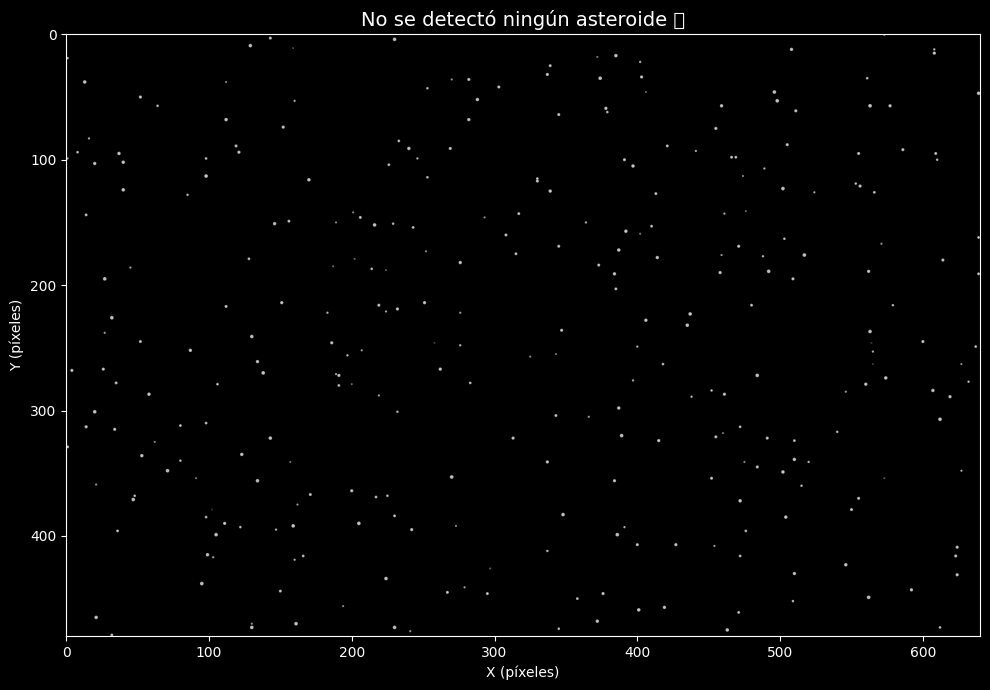

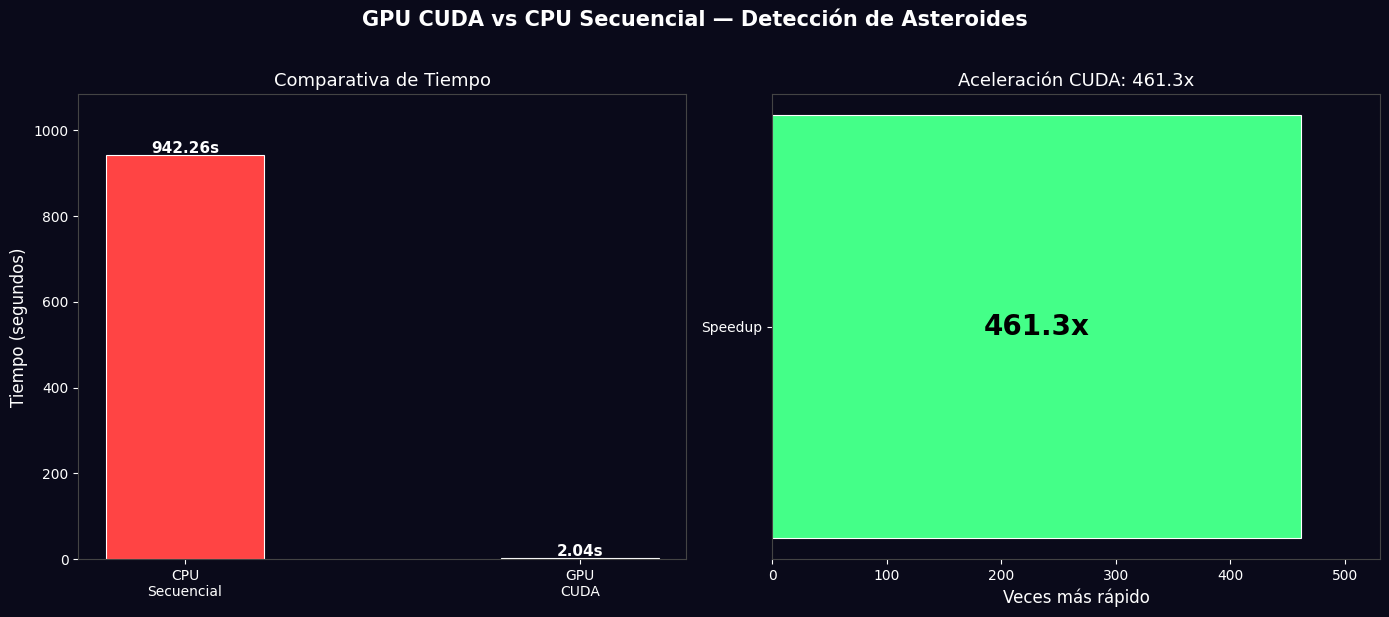


  Tiempo CPU  : 942.26 s
  Tiempo GPU  : 2.04 s
  Speedup     : 461.3x
  Reducción   : 99.8% menos tiempo


In [271]:
# 4. Pipeline GPU
print("="*40)
print("Ejecutando pipeline GPU...")
inicio = time.time()
trayectoria_gpu = pipeline_gpu("asteroide_test_h264.mp4")
tiempo_gpu = time.time() - inicio
print(f"Tiempo GPU : {tiempo_gpu:.2f} s")
print(f"Veredicto  : {'EXISTE ASTEROIDE ☄️' if len(trayectoria_gpu) > 0 else 'NO EXISTE ASTEROIDE 🌌'}")

# 5. Pipeline CPU
print("="*40)
print("Ejecutando pipeline CPU (esto tarda varios minutos)...")
inicio = time.time()
trayectoria_cpu = pipeline_cpu("asteroide_test_h264.mp4")
tiempo_cpu = time.time() - inicio
print(f"Tiempo CPU : {tiempo_cpu:.2f} s")
print(f"Veredicto  : {'EXISTE ASTEROIDE ☄️' if len(trayectoria_cpu) > 0 else 'NO EXISTE ASTEROIDE 🌌'}")

# 6. Trayectoria
print("="*40)
graficar_trayectoria(trayectoria_gpu)

# 7. Comparativa
graficar_comparativa(tiempo_cpu, tiempo_gpu)